## Experiments

In [ ]:
# Set system path

from pathlib import Path
import sys


def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for d in (p, *p.parents):
        if (d / ".git").exists() or (d / "pyproject.toml").exists() or (d / "src").exists():
            return d
    return p  # fallback


repo_root = find_repo_root()
print(repo_root)

# This repo uses a "src layout" (the Python package lives in <repo>/src/qlsas),
# but the repo is not installed as a package. Add <repo>/src to sys.path.
src_dir = repo_root / "src"
if src_dir.exists() and str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

# Also add the repo root so you can import top-level modules like
# `linear_systems_problems.random_matrix_generator`.
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [ ]:
# Import QLSAs modules

from qlsas.algorithms.hhl.hhl import HHL
from qlsas.data_loader import StatePrep
from qlsas.transpiler import Transpiler
from qlsas.executer import Executer
from qlsas.post_processor import Post_Processor
from qlsas.solver import QuantumLinearSolver
from qlsas.refiner import Refiner
from linear_systems_problems.random_matrix_generator_v2 import generate_problem

# Import other modules
from datetime import datetime
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

%config InlineBackend.figure_format = "retina"

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

In [ ]:
n = 16
prob = generate_problem(n=n, cond_number=5, sparsity=0.5, seed=0)
A, b = prob["A"], prob["b"]

A  = A / np.linalg.norm(b)
b = b / np.linalg.norm(b)

print(f"A: {A}")
print()
print(f"b: {b}")
print()
print(f"min eigenvalue: {np.min(np.linalg.eigvalsh(A))}")
print(f"max eigenvalue: {np.max(np.linalg.eigvalsh(A))}")
print(f"condition number: {np.linalg.cond(A)}")
print(f"sparsity: {np.sum(A != 0) / (n * n)}")

In [ ]:
oracle = "classical" # "classical" or "quantum"

hhl = HHL(
    state_prep = StatePrep(method='default'),
    readout = 'measure_x', # 'measure_x' or 'swap_test'
    num_qpe_qubits = int(math.log2(len(b))),
    eig_oracle = oracle
)

backend = AerSimulator()
executer = Executer()
processor = Post_Processor()

In [13]:
max_lam = np.max(np.abs(np.linalg.eigvalsh(A)))
t0_opt = np.pi / max_lam   # spectral-norm optimal t0

t0_values = np.linspace(0, 2 * np.pi, 30) if t0_opt < 2 * np.pi else np.linspace(0, t0_opt, 30)
success_rates = []
residual_errors = []

for t0 in t0_values:
    if np.isclose(t0, 0.0):
        # t0=0 causes divide-by-zero in phase-to-eigenvalue mapping
        success_rates.append(np.nan)
        residual_errors.append(np.nan)
        continue

    hhl_circuit = hhl.build_circuit(A, b, t0=t0)
    transpiler = Transpiler(circuit=hhl_circuit, backend=backend, optimization_level=3)
    transpiled_hhl_circuit = transpiler.optimize()

    result = executer.run(
        transpiled_circuit=transpiled_hhl_circuit,
        backend=backend,
        shots=100000,
    )

    solution, success_rate, residual = processor.process_tomography(result, A, b)
    success_rates.append(success_rate)
    residual_errors.append(residual)

>>> Job ID: be637edb-9643-442b-a660-b28a95162ff9
>>> Job Status: DONE      
total shots: 100000
num_successful_shots: 4
success rate: 4e-05
solver residual: 0.9492251449173208
>>> Job ID: c2b988f1-d310-418d-a682-cfa9f3132d32
>>> Job Status: DONE      
total shots: 100000
num_successful_shots: 26
success rate: 0.00026
solver residual: 0.9841654724952974
>>> Job ID: 21b58e5a-8610-4bc2-ae6b-f6c833bf7491
>>> Job Status: DONE      
total shots: 100000
num_successful_shots: 35
success rate: 0.00035
solver residual: 0.9664723090057356
>>> Job ID: 0bb9e2fc-d106-49e5-8db8-ced4a5fb8fd2
>>> Job Status: DONE      
total shots: 100000
num_successful_shots: 49
success rate: 0.00049
solver residual: 0.9786377189246263
>>> Job ID: efa9a7fa-6556-4503-a908-71a77341ae21
>>> Job Status: DONE      
total shots: 100000
num_successful_shots: 60
success rate: 0.0006
solver residual: 0.9907850543674197
>>> Job ID: 7f1dc997-e541-4438-bdaa-47b5ff653d1b
>>> Job Status: DONE      
total shots: 100000
num_successfu

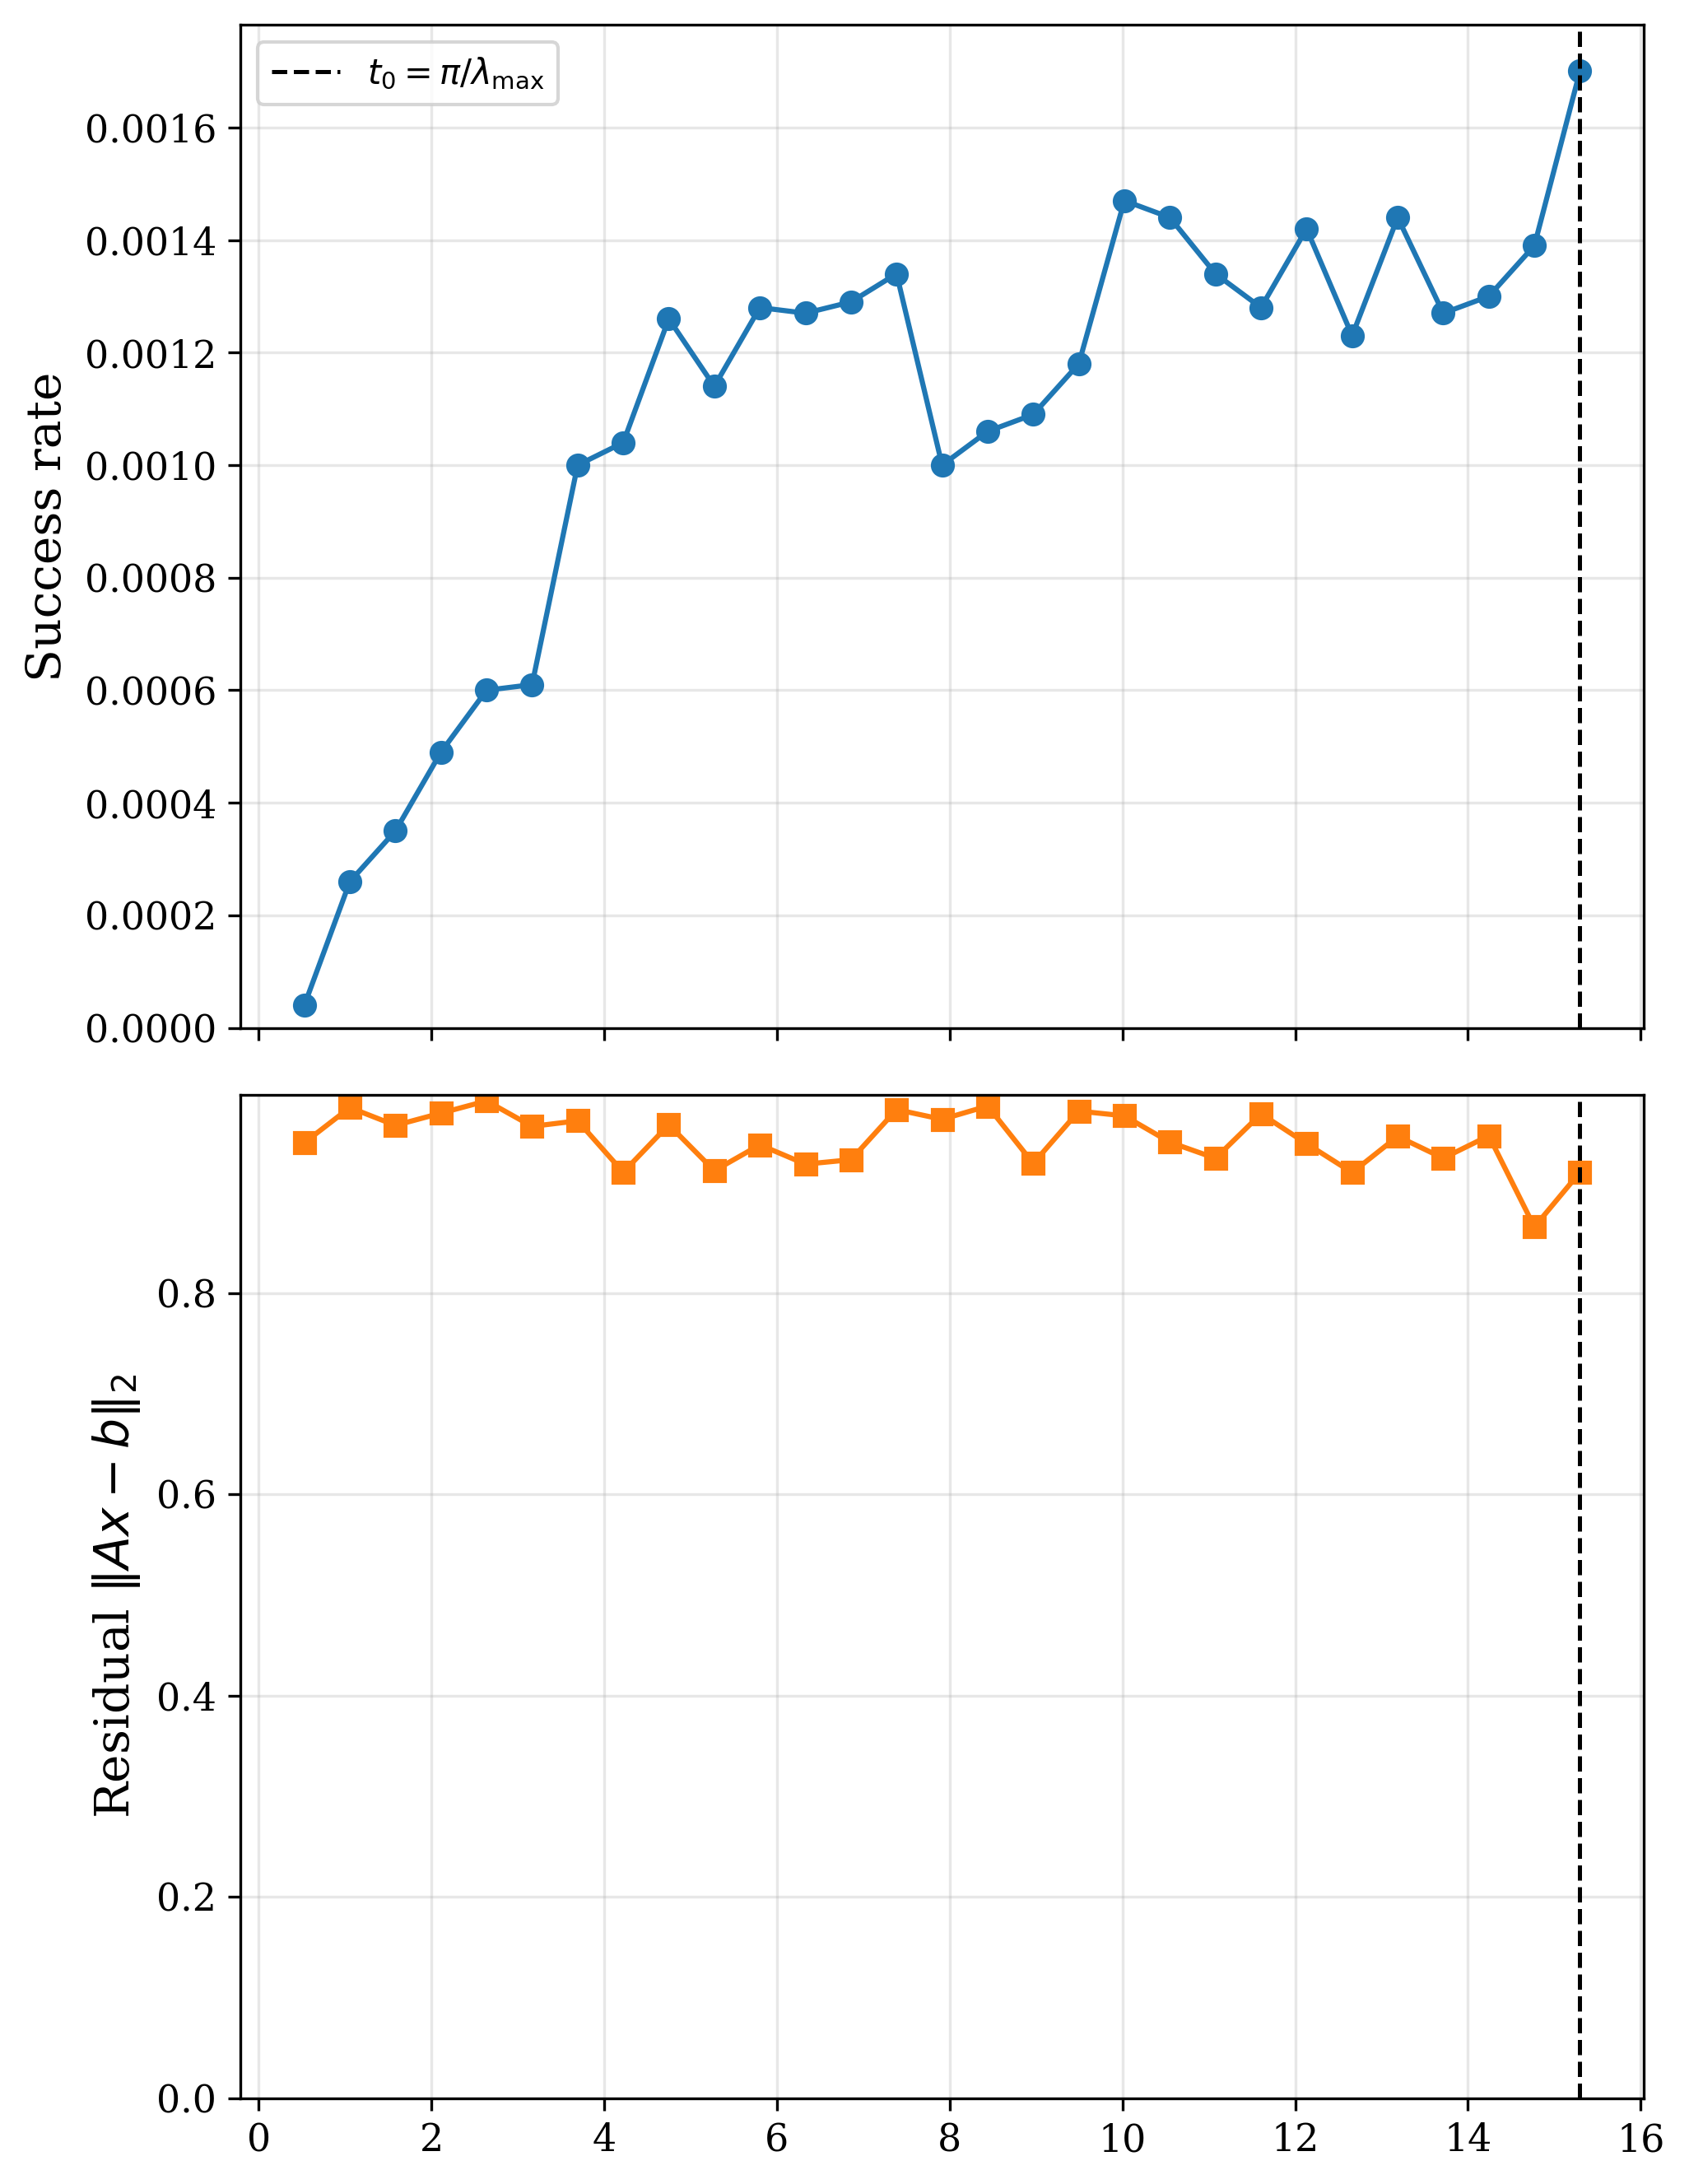

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 9), sharex=True)

# ── Success rate ──────────────────────────────────────────────────────────────
ax1.plot(t0_values, success_rates, marker="o", color="C0", linewidth=1.5)
ax1.axvline(t0_opt, color="black", linestyle="--", linewidth=1.2, label=r"$t_0 = \pi / \lambda_{\max}$")
ax1.set_ylabel("Success rate")
ax1.set_ylim(bottom=0)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ── Residual error ────────────────────────────────────────────────────────────
ax2.plot(t0_values, residual_errors, marker="s", color="C1", linewidth=1.5)
ax2.axvline(t0_opt, color="black", linestyle="--", linewidth=1.2)
ax2.set_ylabel(r"Residual $\|Ax - b\|_2$")
ax2.set_ylim(bottom=0)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"../data/{n}var_t0_sweep_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf")
plt.show()

In [17]:
iterations = 15 #15          # number of IR iterations to plot
max_qpe_qubits = int(math.log2(len(b)) + 1)  # sweep num_qpe_qubits = 1..max_qpe_qubits

# rows: qpe qubits, cols: IR iteration
qpe_residuals = np.full((max_qpe_qubits, iterations), np.nan, dtype=float)
total_circuit_depth = np.full((max_qpe_qubits, iterations), np.nan, dtype=float)

for qpe_qubits in range(1, max_qpe_qubits + 1):
    print(f"================num_qpe_qubits: {qpe_qubits}=================")
    solver = QuantumLinearSolver(
        qlsa=HHL(
            state_prep=StatePrep(method="default"),
            readout="measure_x",
            num_qpe_qubits=qpe_qubits,
            eig_oracle = oracle
        ),
        backend=AerSimulator(),
        target_successful_shots=int(1e3),
        shots_per_batch=int(1e6),
        optimization_level=3,
        executer=executer,
        post_processor=processor,
    )

    refiner = Refiner(A=A, b=b, solver=solver)
    refined_solution = refiner.refine(precision=1e-20, max_iter=iterations-1, plot=False)
    
    r = np.asarray(refined_solution["residuals"], dtype=float)
    qpe_residuals[qpe_qubits - 1, : len(r)] = r

    circuits = refined_solution["transpiled_circuits"]
    depths = np.array([tc.depth() for tc in circuits], dtype=float)
    cumulative_depth = np.cumsum(depths)
    n_depth = min(len(cumulative_depth), total_circuit_depth.shape[1])
    total_circuit_depth[qpe_qubits - 1, :n_depth] = cumulative_depth[:n_depth]

# heatmap of log10 residuals
log_qpe_residuals = np.log10(np.maximum(qpe_residuals, 1e-16))
log_total_depth = np.log10(np.maximum(total_circuit_depth, 1))

================num_qpe_qubits: 1=================
IR Iteration: 0
>>> Job ID: 2430cf95-f00f-4899-bd7b-fae840e18f10
>>> Job Status: DONE      
>>> Job ID: 9467ae6c-4089-4d7d-aaec-4a70bb63cdef
>>> Job Status: DONE      
>>> Job ID: 4e5ecadf-3910-42b5-9b14-7b009568100f
>>> Job Status: DONE      
>>> Job ID: 38f3cf65-0783-4e80-af46-7fa57a6cf20b
>>> Job Status: DONE      
>>> Job ID: 2cace19a-c891-4bd8-93c6-012cf84182f9
>>> Job Status: DONE      
>>> Job ID: 8ee6a0de-7cd4-4159-9a6b-a5659015990d
>>> Job Status: DONE      
>>> Job ID: 75c2076c-9498-41a1-9597-fa0883f4b7eb
>>> Job Status: DONE      
>>> Job ID: 95a57a32-a059-4e8c-8df0-76bae083e615
>>> Job Status: DONE      
>>> Job ID: e1ed6a1b-f679-4441-beef-0fa8c0a8e572
>>> Job Status: DONE      
>>> Job ID: 70afd7f2-083d-4cf5-9206-c31ead6fa91c
>>> Job Status: DONE      
>>> Job ID: eeede05c-1c72-45a5-9c6a-cdadc03ae9f4
>>> Job Status: DONE      
>>> Job ID: 4699df57-89f7-4ea1-bc76-eff0dc36e3da
>>> Job Status: DONE      
>>> Job ID: c9ac447a-

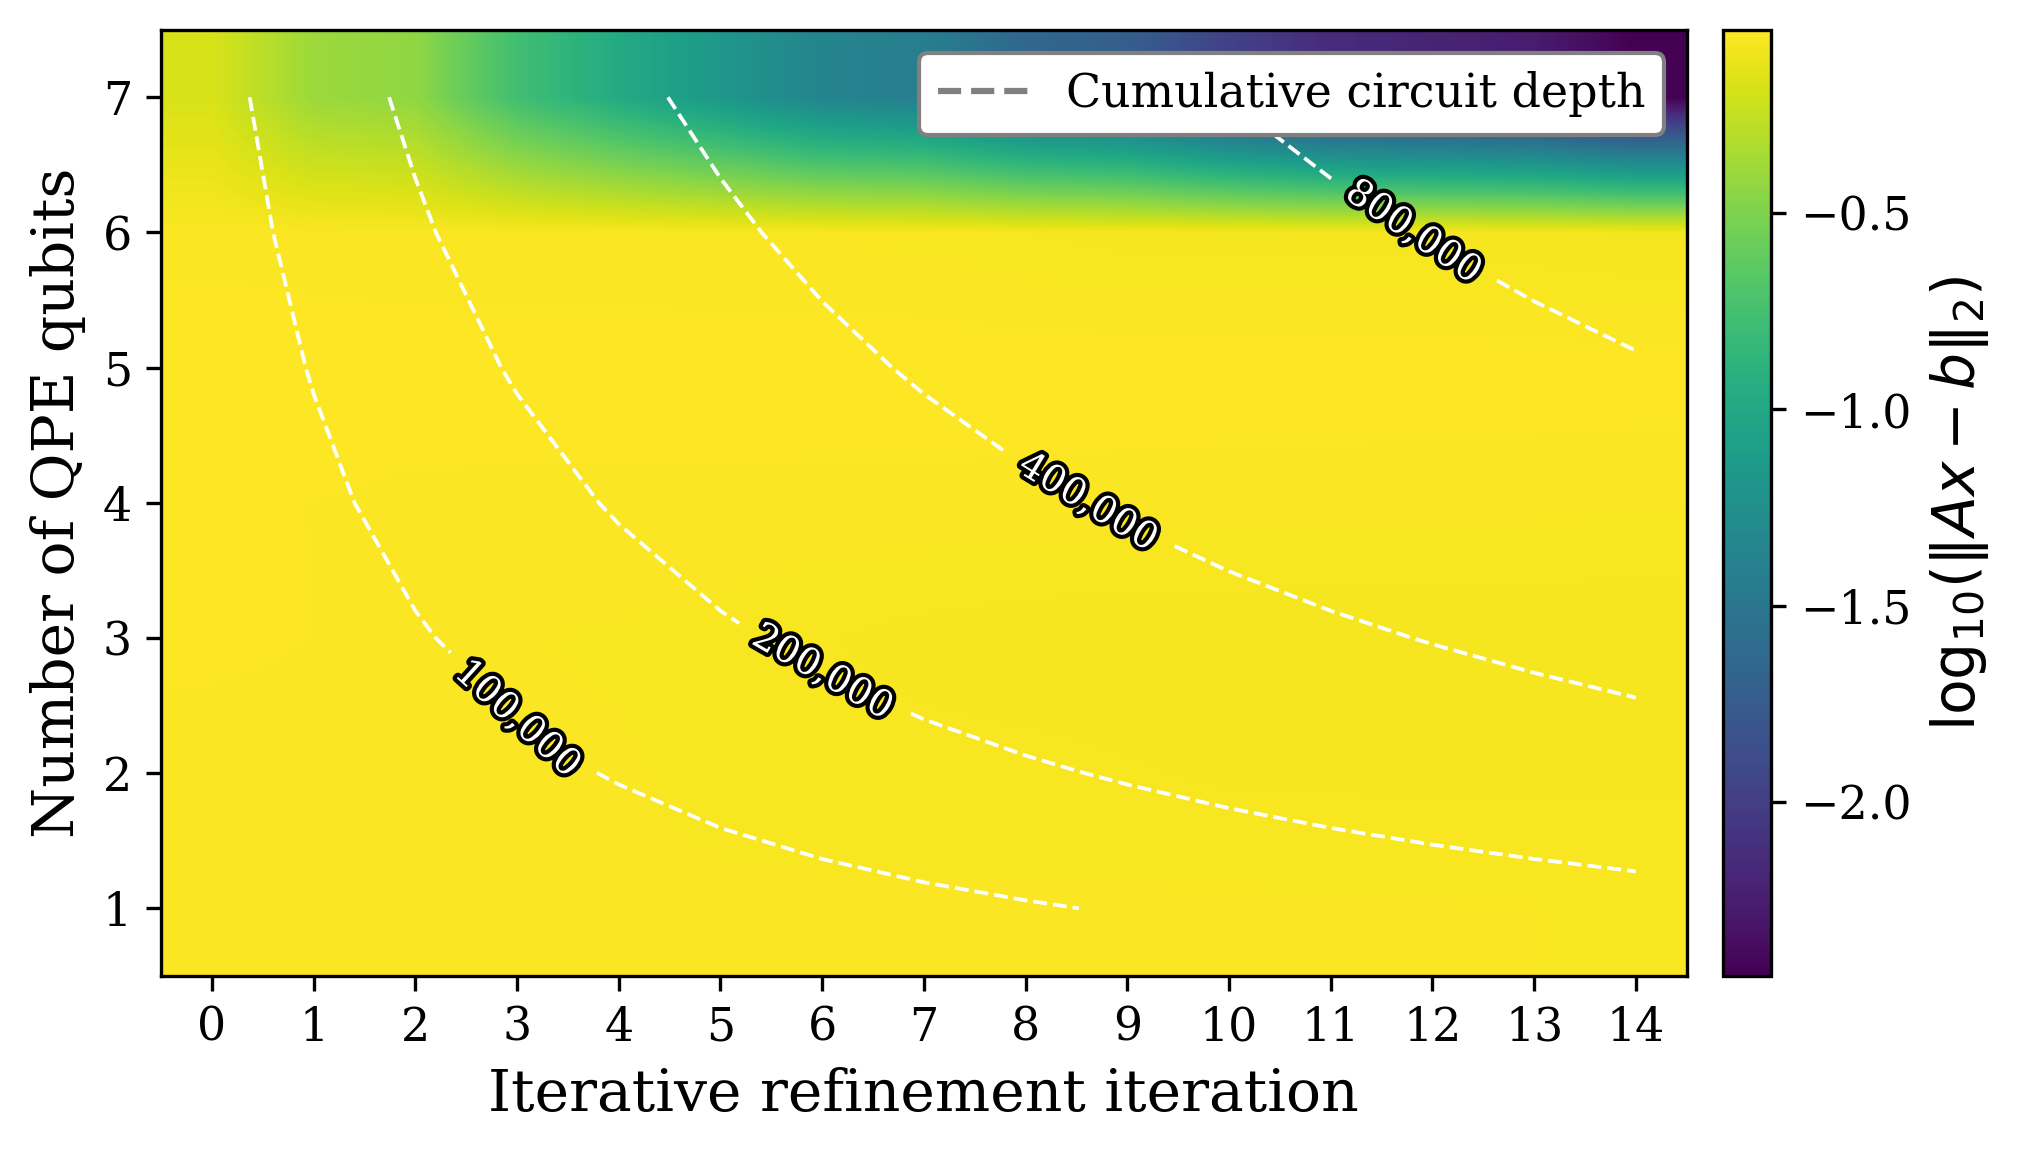

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(
    log_qpe_residuals,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    interpolation="bilinear",
)

ax.set_xlabel("Iterative refinement iteration")
ax.set_ylabel("Number of QPE qubits")

ax.set_xticks(np.arange(total_circuit_depth.shape[1]))
ax.set_yticks(np.arange(total_circuit_depth.shape[0]))
ax.set_yticklabels(np.arange(1, total_circuit_depth.shape[0] + 1))

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(r"$\log_{10}\!\left(\|Ax - b\|_2\right)$")
cbar.ax.tick_params(labelsize=11)

X, Y = np.meshgrid(np.arange(total_circuit_depth.shape[1]), np.arange(total_circuit_depth.shape[0]))
cs = ax.contour(X, Y, total_circuit_depth, levels=[100000, 200000, 400000, 800000],
                colors="white", linestyles="--", linewidths=0.9)
labels = ax.clabel(cs, fmt=lambda v: f"{int(v):,}", fontsize=9, colors="white")
outline = [pe.withStroke(linewidth=2, foreground="black")]
for lbl in labels:
    lbl.set_path_effects(outline)

ax.plot([], [], ls="--", color="gray", label="Cumulative circuit depth")
ax.legend(loc="upper right", facecolor="white", framealpha=1.0, edgecolor="gray")

plt.tight_layout()
plt.savefig(f"../data/{n}var_qpe_vs_ir_residuals_with_overlay_cond_{prob['cond_number']:.2f}_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf")plt.show()

In [ ]:
# fig, ax = plt.subplots(figsize=(7, 4))
# im = ax.imshow(
#     total_circuit_depth,
#     origin="lower",
#     aspect="auto",
#     cmap="magma",
#     interpolation="nearest",
# )

# ax.set_xlabel("Iterative refinement iteration")
# ax.set_ylabel("Number of QPE qubits")

# ax.set_xticks(np.arange(total_circuit_depth.shape[1]))
# ax.set_yticks(np.arange(total_circuit_depth.shape[0]))
# ax.set_yticklabels(np.arange(1, total_circuit_depth.shape[0] + 1))

# cbar = fig.colorbar(im, ax=ax)
# cbar.set_label(r"$\mathrm{cumulative\ circuit\ depth}$")

# plt.tight_layout()
# plt.show()

In [20]:
iterations = 11 #11          # number of IR iterations to plot (0..iterations-1)
shots = np.linspace(1, 1000, 11, dtype=int)

# rows: shot counts, cols: IR iteration
shot_residuals = np.full((len(shots), iterations), np.nan, dtype=float)


num_qpe_qubits = int(math.log2(len(b)))

for i, shot_count in enumerate(shots):
    print(f"================shots: {shot_count}=================")
    solver = QuantumLinearSolver(
        qlsa=HHL(
            state_prep=StatePrep(method="default"),
            readout="measure_x",
            num_qpe_qubits=num_qpe_qubits,
            eig_oracle = oracle
        ),
        backend=AerSimulator(),
        target_successful_shots=shot_count,
        shots_per_batch=100 * shot_count,
        optimization_level=3,
        executer=executer,
        post_processor=processor,
    )

    refiner = Refiner(A=A, b=b, solver=solver)
    refined_solution = refiner.refine(precision=1e-20, max_iter=iterations-1, plot=False)

    r = np.asarray(refined_solution["residuals"], dtype=float)
    shot_residuals[i, : len(r)] = r

# heatmap of log10 residuals
log_shot_residuals = np.log10(np.maximum(shot_residuals, 1e-16))

================shots: 1=================
IR Iteration: 0
>>> Job ID: bfa58a84-9127-4c49-bb49-dccffc3b0c24
>>> Job Status: DONE      
  residual: 0.9843, error: 1.3547, alpha: 2.2788

IR Iteration: 1
>>> Job ID: 1e51cca8-4d70-4ffb-8834-870c634931db
>>> Job Status: DONE      
>>> Job ID: 24369f67-2962-436b-8536-9e8418952032
>>> Job Status: DONE      
>>> Job ID: 3fc006e3-aabe-44fe-946c-474b07090c3d
>>> Job Status: DONE      
>>> Job ID: 285c1a86-72b5-4108-bacf-2ffcc8e92463
>>> Job Status: DONE      
>>> Job ID: a0877d71-8b66-4398-9f49-f1b143466ff3
>>> Job Status: DONE      
>>> Job ID: d6667727-09cc-47c3-98ff-0291bd9d634d
>>> Job Status: DONE      
>>> Job ID: f315fac4-90b7-404a-9368-89a5ca8547e2
>>> Job Status: DONE      
  residual: 0.9825, error: 1.2848, alpha: 0.9030

IR Iteration: 2
>>> Job ID: 64326098-c7df-4648-a1a9-df54896025fb
>>> Job Status: DONE      
>>> Job ID: 3e288e89-9a4d-4bd3-81a8-d792af0ec3c1
>>> Job Status: DONE      
>>> Job ID: f7a7fa36-dd8a-48ee-aa3c-2fee37da6eac
>

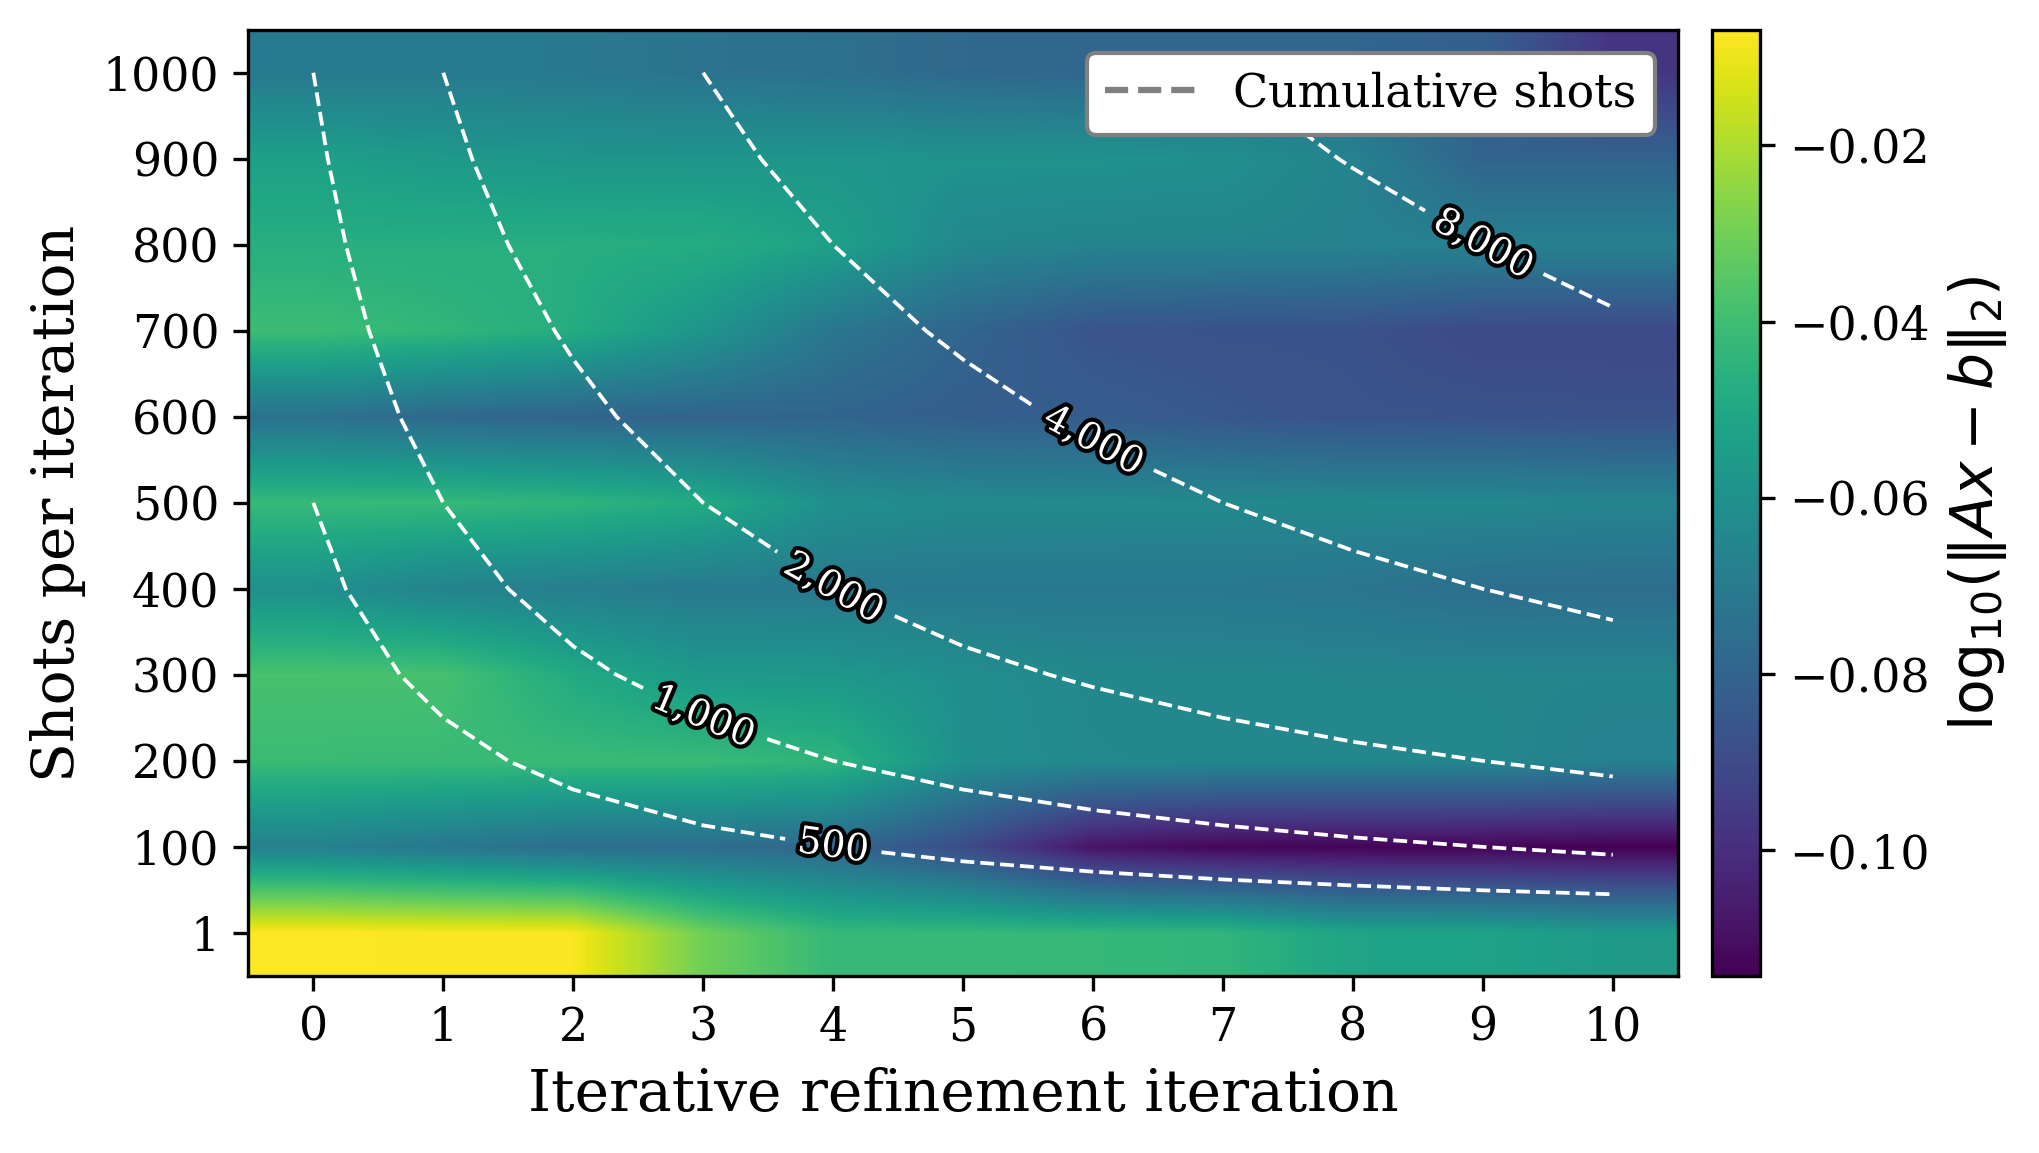

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(
    log_shot_residuals,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    interpolation="bilinear",
)

ax.set_xlabel("Iterative refinement iteration")
ax.set_ylabel("Shots per iteration")

ax.set_xticks(np.arange(iterations))
ax.set_yticks(np.arange(len(shots)))
ax.set_yticklabels(shots)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(r"$\log_{10}\!\left(\|Ax - b\|_2\right)$")
cbar.ax.tick_params(labelsize=11)

X, Y = np.meshgrid(np.arange(iterations), np.arange(len(shots)))
cumulative_shots = shots[:, None] * (X + 1)
levels = [500, 1000, 2000, 4000, 8000]
cs = ax.contour(X, Y, cumulative_shots, levels=levels,
                colors="white", linestyles="--", linewidths=0.9)
labels = ax.clabel(cs, fmt=lambda v: f"{int(v):,}", fontsize=9, colors="white")
outline = [pe.withStroke(linewidth=2, foreground="black")]
for lbl in labels:
    lbl.set_path_effects(outline)

ax.plot([], [], ls="--", color="gray", label="Cumulative shots")
ax.legend(loc="upper right", facecolor="white", framealpha=1.0, edgecolor="gray")

plt.tight_layout()
plt.savefig(f"../data/{n}var_shots_vs_ir_residuals_with_overlay_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf")
plt.show()

In [22]:
max_qpe_qubits = 6
shot_values = np.linspace(1, 200, 21, dtype=int)

single_solve_residuals = np.full((max_qpe_qubits, len(shot_values)), np.nan, dtype=float)

prob = generate_problem(n=n, cond_number=5.0, sparsity=0.5, seed=0)
A, b = prob["A"], prob["b"]
A = A / np.linalg.norm(b)
b = b / np.linalg.norm(b)
x_classical = np.linalg.solve(A, b)

for qi, qpe_qubits in enumerate(range(1, max_qpe_qubits + 1)):
    for si, shot_count in enumerate(shot_values):
        print(f"qpe={qpe_qubits}, shots={shot_count}")
        solver = QuantumLinearSolver(
            qlsa=HHL(
                state_prep=StatePrep(method="default"),
                readout="measure_x",
                num_qpe_qubits=qpe_qubits,
                eig_oracle = oracle
            ),
            backend=AerSimulator(),
            target_successful_shots=int(shot_count),
            shots_per_batch=5 * int(shot_count),
            optimization_level=3,
            executer=executer,
            post_processor=processor,
        )
        x_q = solver.solve(A, b, verbose=False)
        alpha = np.dot(A @ x_q, b) / np.dot(A @ x_q, A @ x_q)
        x_scaled = alpha * x_q
        single_solve_residuals[qi, si] = np.linalg.norm(b - A @ x_scaled)

log_single_residuals = np.log10(np.maximum(single_solve_residuals, 1e-16))

qpe=1, shots=1
qpe=1, shots=10
qpe=1, shots=20
qpe=1, shots=30
qpe=1, shots=40
qpe=1, shots=50
qpe=1, shots=60
qpe=1, shots=70
qpe=1, shots=80
qpe=1, shots=90
qpe=1, shots=100
qpe=1, shots=110
qpe=1, shots=120
qpe=1, shots=130
qpe=1, shots=140
qpe=1, shots=150
qpe=1, shots=160
qpe=1, shots=170
qpe=1, shots=180
qpe=1, shots=190
qpe=1, shots=200
qpe=2, shots=1
qpe=2, shots=10
qpe=2, shots=20
qpe=2, shots=30
qpe=2, shots=40
qpe=2, shots=50
qpe=2, shots=60
qpe=2, shots=70
qpe=2, shots=80
qpe=2, shots=90
qpe=2, shots=100
qpe=2, shots=110
qpe=2, shots=120
qpe=2, shots=130
qpe=2, shots=140
qpe=2, shots=150
qpe=2, shots=160
qpe=2, shots=170
qpe=2, shots=180
qpe=2, shots=190
qpe=2, shots=200
qpe=3, shots=1
qpe=3, shots=10
qpe=3, shots=20
qpe=3, shots=30
qpe=3, shots=40
qpe=3, shots=50
qpe=3, shots=60
qpe=3, shots=70
qpe=3, shots=80
qpe=3, shots=90
qpe=3, shots=100
qpe=3, shots=110
qpe=3, shots=120
qpe=3, shots=130
qpe=3, shots=140
qpe=3, shots=150
qpe=3, shots=160
qpe=3, shots=170
qpe=3, shots=

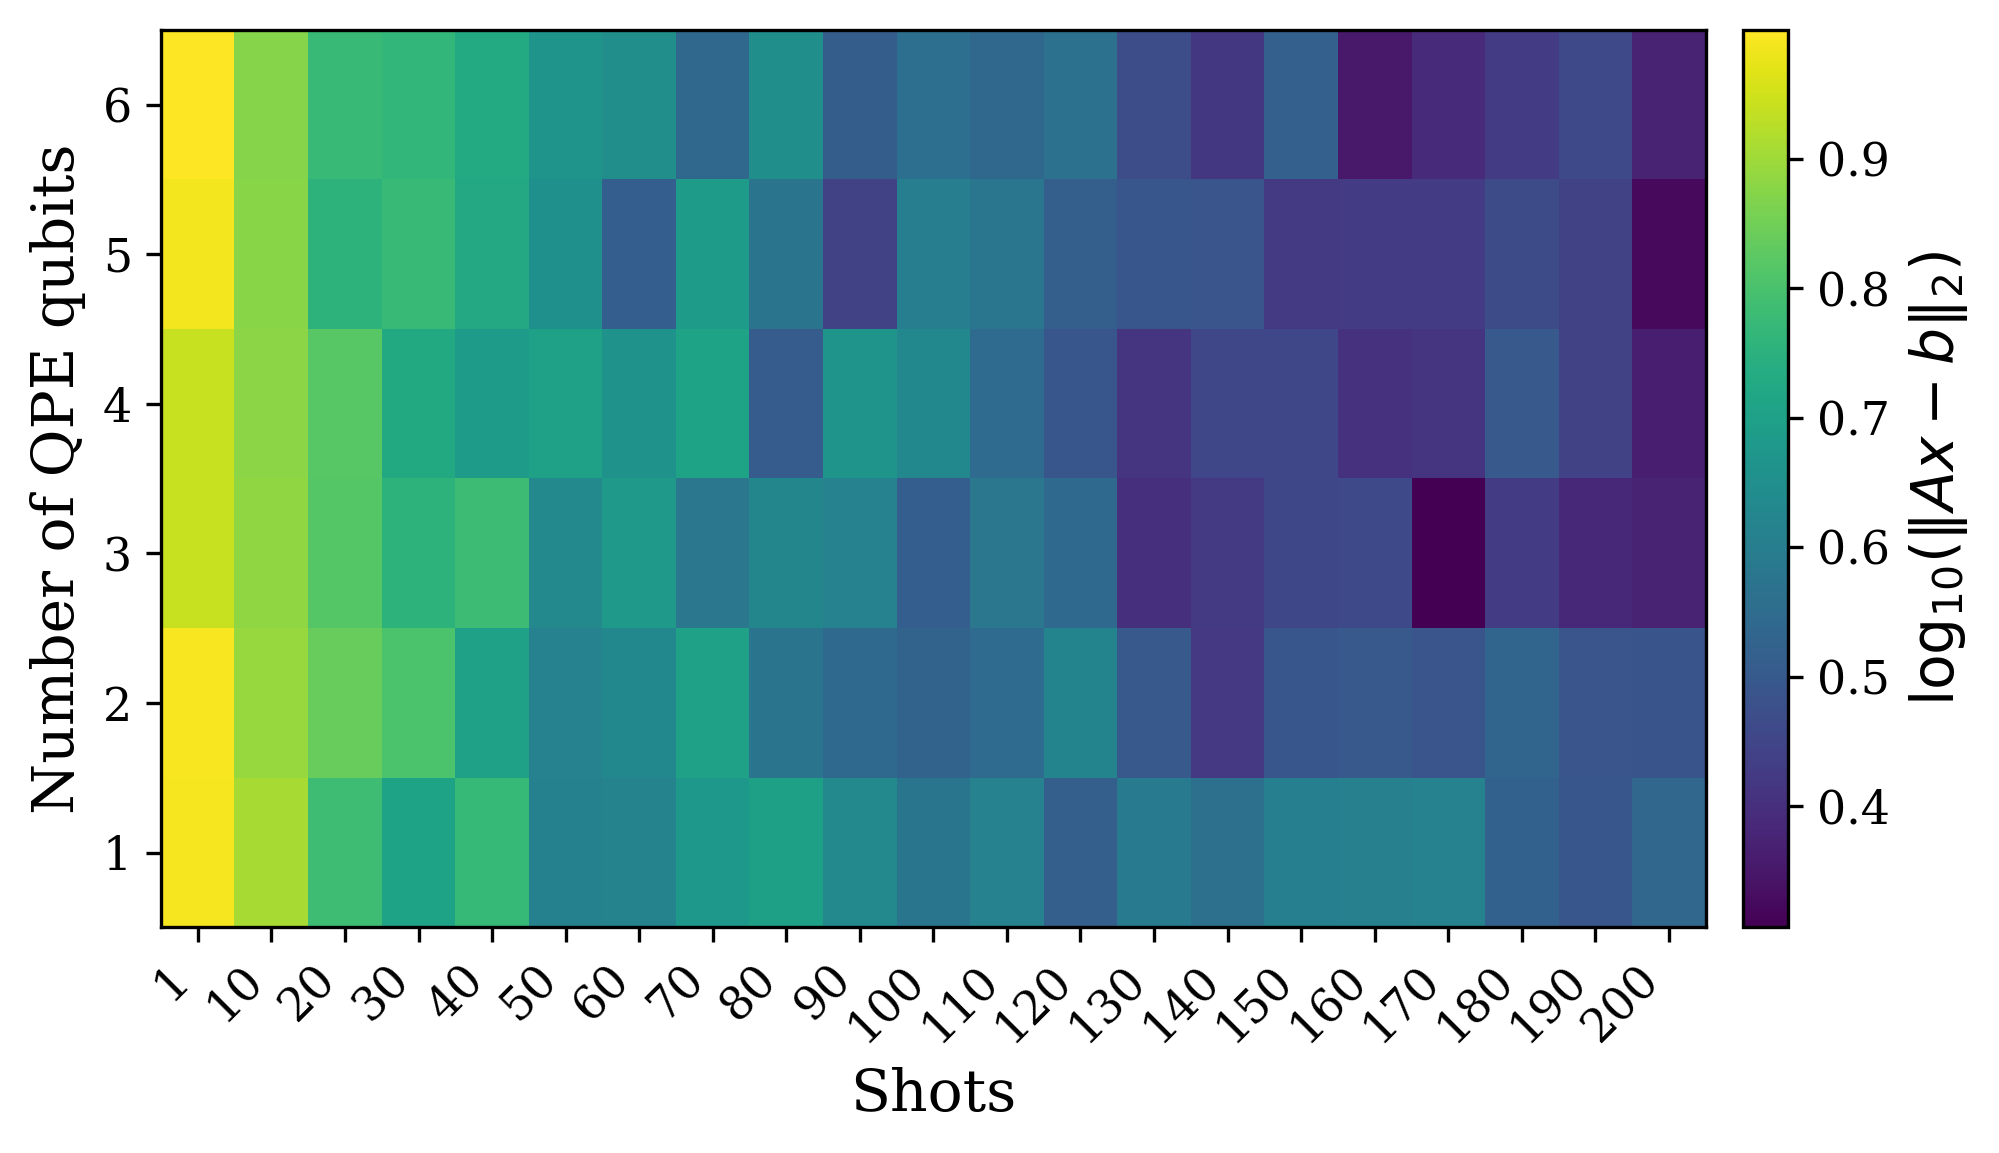

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(
    single_solve_residuals,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    interpolation="nearest",
)

ax.set_xlabel("Shots")
ax.set_ylabel("Number of QPE qubits")

ax.set_xticks(np.arange(len(shot_values)))
ax.set_xticklabels(shot_values, rotation=45, ha="right")
ax.set_yticks(np.arange(max_qpe_qubits))
ax.set_yticklabels(np.arange(1, max_qpe_qubits + 1))

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(r"$\log_{10}\!\left(\|Ax - b\|_2\right)$")
cbar.ax.tick_params(labelsize=11)

plt.tight_layout()
# plt.savefig("qpe_vs_shots_residuals.pdf")
plt.show()

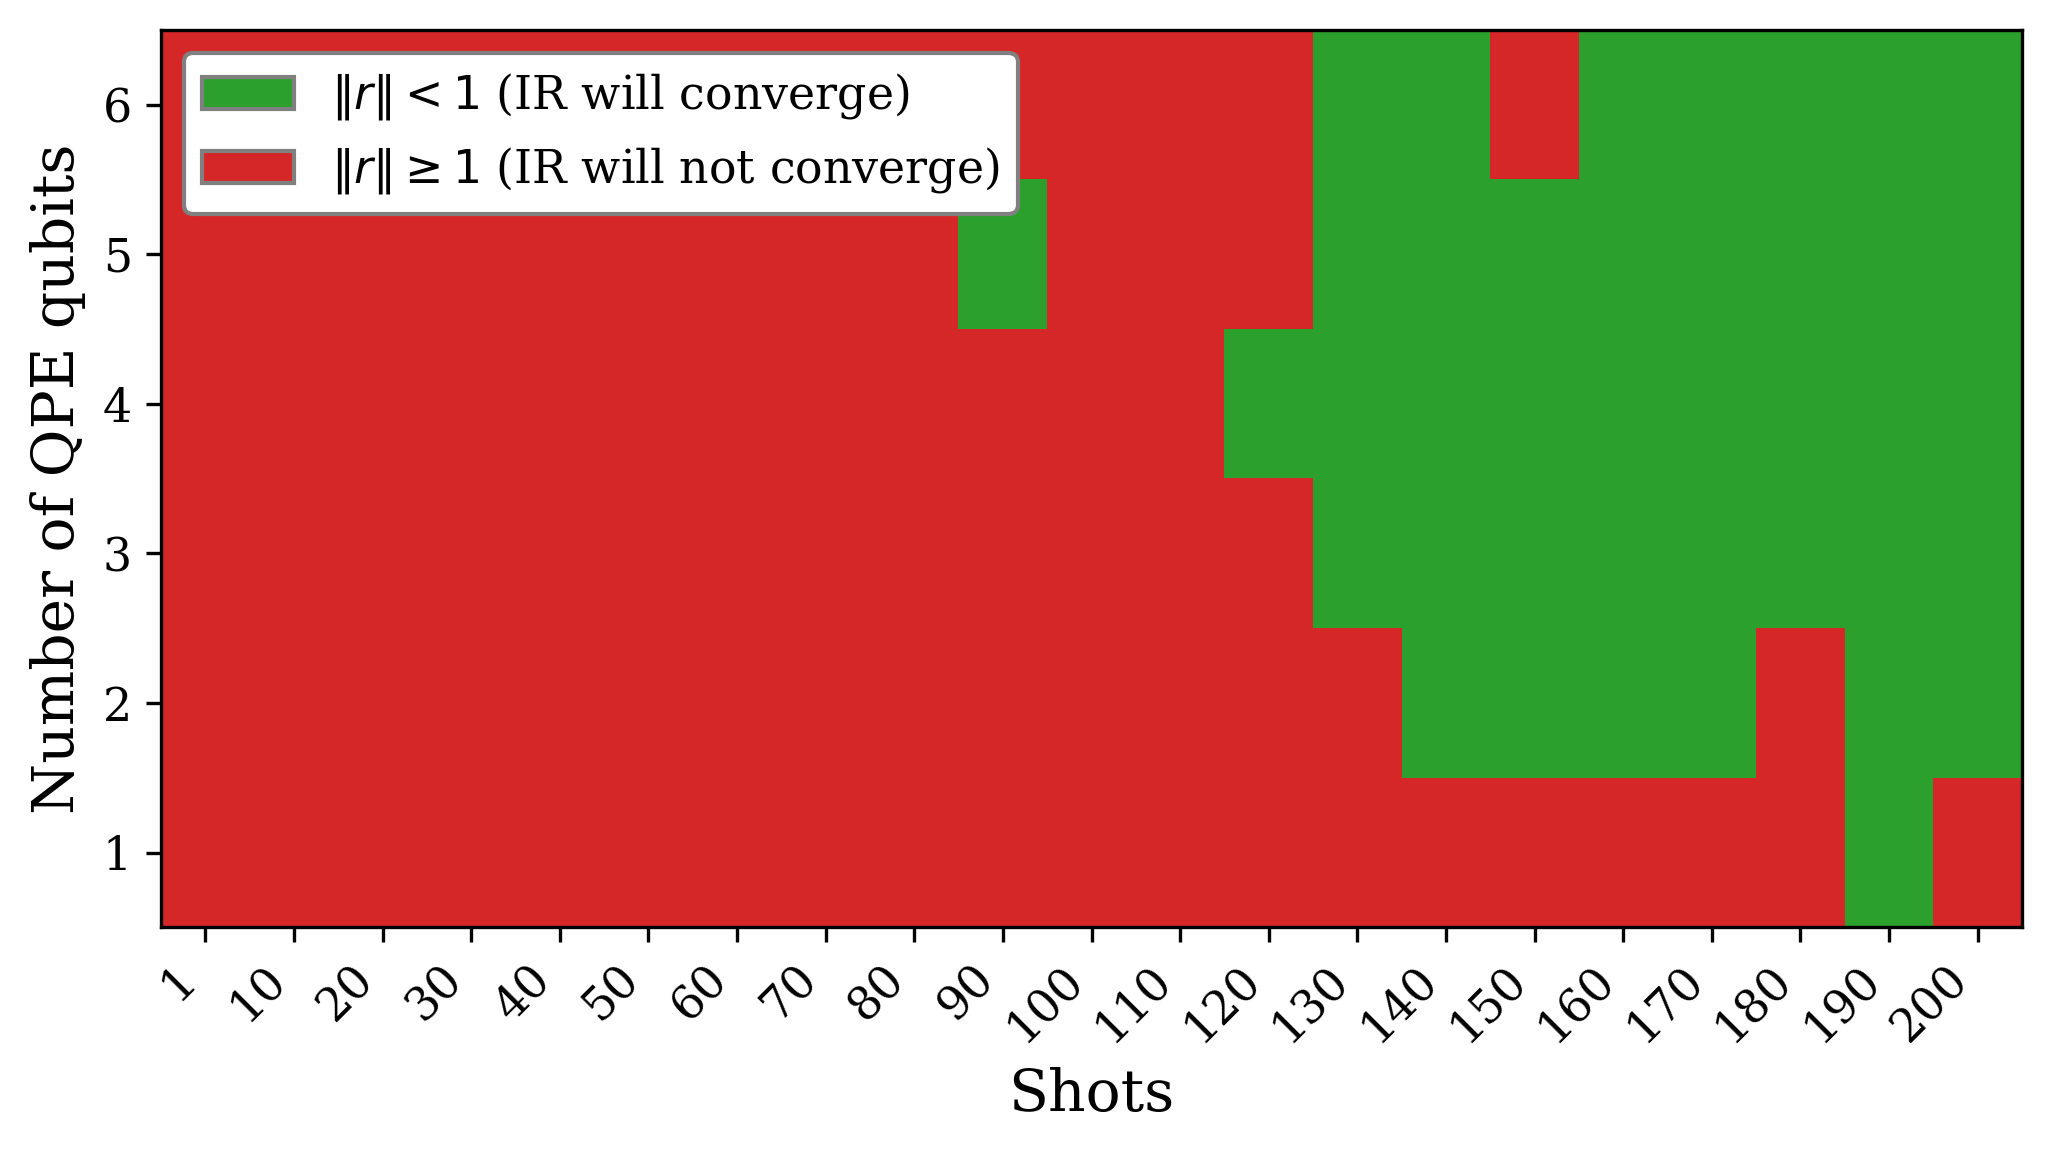

In [24]:
from matplotlib.colors import ListedColormap

converges = single_solve_residuals < .5

cmap_rg = ListedColormap(["#d62728", "#2ca02c"])

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(
    converges.astype(int),
    origin="lower",
    aspect="auto",
    cmap=cmap_rg,
    interpolation="nearest",
    vmin=0,
    vmax=1,
)

ax.set_xlabel("Shots")
ax.set_ylabel("Number of QPE qubits")

ax.set_xticks(np.arange(len(shot_values)))
ax.set_xticklabels(shot_values, rotation=45, ha="right")
ax.set_yticks(np.arange(max_qpe_qubits))
ax.set_yticklabels(np.arange(1, max_qpe_qubits + 1))

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="#2ca02c", edgecolor="gray", label=r"$\|r\| < 1$ (IR will converge)"),
    Patch(facecolor="#d62728", edgecolor="gray", label=r"$\|r\| \geq 1$ (IR will not converge)"),
]
ax.legend(handles=legend_handles, loc="upper left", facecolor="white", framealpha=1.0, edgecolor="gray")

plt.tight_layout()
# plt.savefig("qpe_vs_shots_convergence.pdf")
plt.show()